In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import load_model

import warnings
warnings.filterwarnings("ignore")

I0000 00:00:1786350896.222461  341605 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786350896.276683  341605 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786350898.009895  341605 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
df = pd.read_csv("dataset/pjm_processed.csv")

df.head()

,timestamp,demand,hour,day_of_week,month,day,week,year,is_weekend,lag_1,lag_48,lag_168,rolling_mean_24,rolling_mean_168,rolling_std_24,rolling_std_168,period,lag_24
0,2002-01-08 01:00:00,29445.0,1,1,1,8,2,2002,0,31187.0,27100.0,30393.0,33452.583333,32519.511905,4425.965952,3857.950565,Off-Peak,NaN
1,2002-01-08 02:00:00,28670.0,2,1,1,8,2,2002,0,29445.0,26097.0,29265.0,33560.208333,32513.869048,4256.159403,3861.770954,Off-Peak,NaN
2,2002-01-08 03:00:00,28375.0,3,1,1,8,2,2002,0,28670.0,25793.0,28357.0,33672.458333,32510.327381,4064.104959,3865.039821,Off-Peak,NaN
3,2002-01-08 04:00:00,28542.0,4,1,1,8,2,2002,0,28375.0,25657.0,27899.0,33786.375000,32510.434524,3851.076461,3864.924245,Off-Peak,NaN
4,2002-01-08 05:00:00,29261.0,5,1,1,8,2,2002,0,28542.0,25778.0,28057.0,33906.208333,32514.261905,3640.941409,3860.646270,Off-Peak,NaN


In [3]:
features = [
    "demand",
    "lag_1",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_24",
    "rolling_std_24",
    "rolling_mean_168",
    "rolling_std_168"
]

target = "demand"

print("Features:")
print(features)

Features:
['demand', 'lag_1', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168', 'rolling_std_168']


In [4]:
df["rolling_mean_24"] = (
    df["demand"]
    .shift(1)
    .rolling(24)
    .mean()
)

df["rolling_std_24"] = (
    df["demand"]
    .shift(1)
    .rolling(24)
    .std()
)

df["rolling_mean_168"] = (
    df["demand"]
    .shift(1)
    .rolling(168)
    .mean()
)

df["rolling_std_168"] = (
    df["demand"]
    .shift(1)
    .rolling(168)
    .std()
)

In [5]:
df = df.dropna().reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("Missing values:", df[features].isna().sum().sum())

Shape after cleaning: (145056, 18)
Missing values: 0


In [6]:
test_size = int(len(df) * 0.20)

test_start = len(df) - test_size

remaining = df.iloc[:test_start]

test = df.iloc[test_start:]

In [7]:
validation_hours = 30 * 24

validation_start = len(remaining) - validation_hours

train = remaining.iloc[:validation_start]

validation = remaining.iloc[validation_start:]

In [8]:
print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (115325, 18)
Validation: (720, 18)
Test: (29011, 18)


In [9]:
feature_scaler = MinMaxScaler()

train_scaled = feature_scaler.fit_transform(
    train[features]
)

validation_scaled = feature_scaler.transform(
    validation[features]
)

test_scaled = feature_scaler.transform(
    test[features]
)

In [10]:
target_scaler = MinMaxScaler()

target_train_scaled = target_scaler.fit_transform(
    train[[target]]
)

target_validation_scaled = target_scaler.transform(
    validation[[target]]
)

target_test_scaled = target_scaler.transform(
    test[[target]]
)

In [11]:
import joblib

joblib.dump(
    feature_scaler,
    "feature_scaler.pkl"
)

joblib.dump(
    target_scaler,
    "target_scaler.pkl"
)

print("Scalers saved successfully!")

Scalers saved successfully!


In [12]:
def create_sequences(
    X_data,
    y_data,
    input_length=168,
    output_length=24
):

    X = []
    y = []

    for i in range(
        len(X_data) - input_length - output_length + 1
    ):

        X.append(
            X_data[
                i:i + input_length
            ]
        )

        y.append(
            y_data[
                i + input_length:
                i + input_length + output_length
            ]
        )

    return np.array(X), np.array(y)

In [13]:
val_X_input = np.concatenate([
    train_scaled[-168:],
    validation_scaled
])

val_y_input = np.concatenate([
    target_train_scaled[-168:],
    target_validation_scaled
])

In [14]:
X_val, y_val = create_sequences(
    val_X_input,
    val_y_input,
    input_length=168,
    output_length=24
)

In [15]:
y_val = y_val.reshape(
    y_val.shape[0],
    24
)

In [16]:
final_model = load_model(
    "final_gru_forecasting_model11.keras"
)

E0000 00:00:1786350899.106505  341605 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [17]:
y_val_pred = final_model.predict(
    X_val,
    verbose=1
)

print("Prediction shape:", y_val_pred.shape)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
Prediction shape: (697, 24)


In [18]:
print("Prediction sample:")
print(y_val_pred[0])

print("\nActual scaled sample:")
print(y_val[0])

Prediction sample:
[0.34628358 0.35277575 0.4083193  0.41856948 0.41463655 0.3755928
 0.36629742 0.3498357  0.38560328 0.3396747  0.3196222  0.36710703
 0.35249877 0.41377056 0.40690422 0.3773107  0.3957826  0.34168336
 0.31214723 0.30353302 0.28313047 0.2208099  0.24824741 0.2763273 ]

Actual scaled sample:
[0.33178131 0.41506373 0.45880122 0.44590751 0.41765511 0.39865164
 0.37754135 0.3603076  0.35061624 0.33978721 0.33660592 0.34252607
 0.35647319 0.37103129 0.39631307 0.39172021 0.36865058 0.33321395
 0.2938797  0.26054988 0.24026125 0.2293058  0.22422838 0.22637733]


In [19]:
def inverse_target(data):

    original_shape = data.shape

    data = data.reshape(-1, 1)

    data = target_scaler.inverse_transform(
        data
    )

    return data.reshape(original_shape)

In [20]:
y_val_actual = inverse_target(y_val)

y_val_forecast = inverse_target(y_val_pred)

In [21]:
print("Actual:")
print(y_val_actual[0])

print("\nForecast:")
print(y_val_forecast[0])

Actual:
[30292. 34245. 36321. 35709. 34368. 33466. 32464. 31646. 31186. 30672.
 30521. 30802. 31464. 32155. 33355. 33137. 32042. 30360. 28493. 26911.
 25948. 25428. 25187. 25289.]

Forecast:
[30980.35  31288.502 33924.875 34411.4   34224.723 32371.512 31930.307
 31148.951 32846.66  30666.66  29714.865 31968.736 31275.354 34183.62
 33857.71  32453.053 33329.82  30762.    29360.066 28951.195 27982.787
 25024.74  26327.062 27659.877]


In [22]:
actual_30 = y_val_actual.flatten()

forecast_30 = y_val_forecast.flatten()

print(actual_30.shape)
print(forecast_30.shape)

(16728,)
(16728,)


In [23]:
def evaluate_forecast(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mape = np.mean(
        np.abs(
            (y_true - y_pred) / y_true
        )
    ) * 100

    r2 = r2_score(
        y_true,
        y_pred
    )

    bias = np.mean(
        y_pred - y_true
    )

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2,
        "Bias": bias
    }

In [24]:
results_30 = evaluate_forecast(
    actual_30,
    forecast_30
)

results_30

{'MAE': 1464.0293845601311,
 'MSE': 3547787.271183291,
 'RMSE': np.float64(1883.5570793536604),
 'MAPE': np.float64(5.028452610724245),
 'R2': 0.7281301721323956,
 'Bias': np.float64(149.7976335756292)}

In [25]:
validation_30_df = pd.DataFrame(
    [results_30]
)

validation_30_df

,MAE,MSE,RMSE,MAPE,R2,Bias
0,1464.029385,3.547787e+06,1883.557079,5.028453,0.72813,149.797634


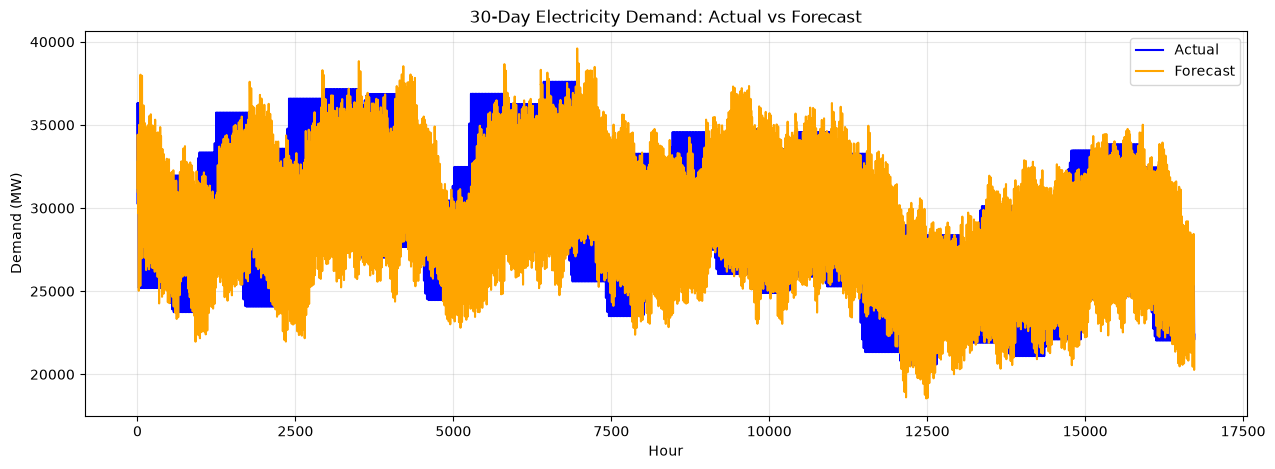

In [26]:
plt.figure(figsize=(15, 5))

plt.plot(
    actual_30,
    label="Actual",
    color="blue"
)

plt.plot(
    forecast_30,
    label="Forecast",
    color="orange"
)

plt.title(
    "30-Day Electricity Demand: Actual vs Forecast"
)

plt.xlabel("Hour")

plt.ylabel("Demand (MW)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [27]:
complete_hours = (
    len(actual_30) // 24
) * 24

daily_mae = np.abs(
    actual_30[:complete_hours]
    - forecast_30[:complete_hours]
).reshape(-1, 24).mean(axis=1)

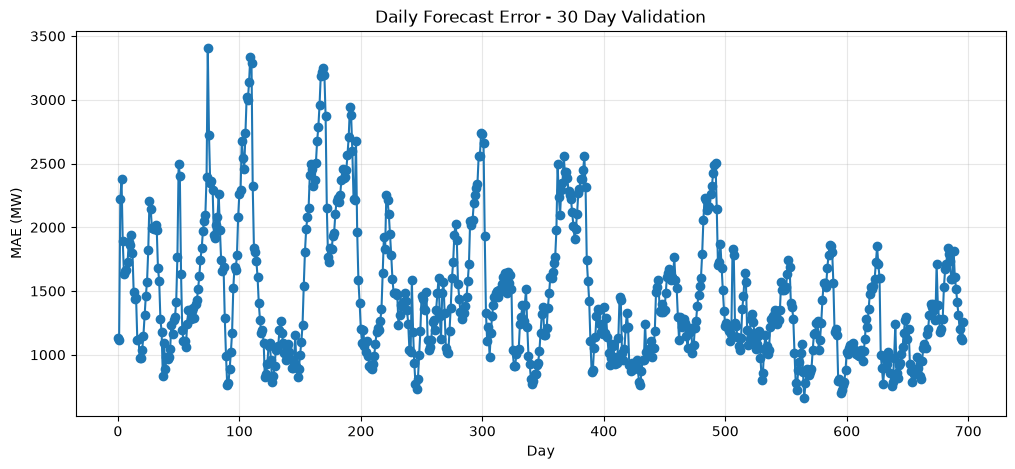

In [28]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_mae,
    marker="o"
)

plt.title(
    "Daily Forecast Error - 30 Day Validation"
)

plt.xlabel("Day")

plt.ylabel("MAE (MW)")

plt.grid(alpha=0.3)

plt.show()

In [29]:
#Peak demand error



peak_threshold = np.percentile(
    actual_30,
    90
)

peak_mask = actual_30 >= peak_threshold
peak_mae = mean_absolute_error(
    actual_30[peak_mask],
    forecast_30[peak_mask]
)

print(
    "Peak Demand MAE:",
    peak_mae
)


Peak Demand MAE: 1948.9145674992621


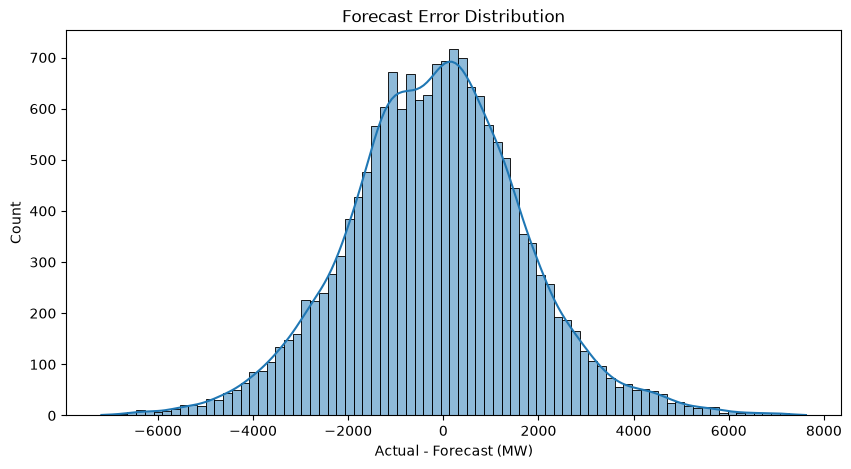

In [30]:
# Error distribution
errors = (
    actual_30 - forecast_30
)

plt.figure(figsize=(10, 5))

sns.histplot(
    errors,
    kde=True
)

plt.title(
    "Forecast Error Distribution"
)

plt.xlabel(
    "Actual - Forecast (MW)"
)

plt.show()

In [31]:
validation_30_df.to_csv(
    "phase7_30_day_validation.csv",
    index=False
)

In [32]:
# 60-day validation

validation_hours = 60 * 24

validation_start = len(remaining) - validation_hours

train_60 = remaining.iloc[:validation_start]

validation_60 = remaining.iloc[validation_start:]

print("Train:", train_60.shape)
print("Validation:", validation_60.shape)

Train: (114605, 18)
Validation: (1440, 18)


In [33]:
feature_scaler_60 = MinMaxScaler()

train_60_scaled = feature_scaler_60.fit_transform(
    train_60[features]
)

validation_60_scaled = feature_scaler_60.transform(
    validation_60[features]
)

In [34]:
target_scaler_60 = MinMaxScaler()

target_train_60_scaled = target_scaler_60.fit_transform(
    train_60[["demand"]]
)

target_validation_60_scaled = target_scaler_60.transform(
    validation_60[["demand"]]
)

In [35]:
val_60_X_input = np.concatenate([
    train_60_scaled[-168:],
    validation_60_scaled
])

val_60_y_input = np.concatenate([
    target_train_60_scaled[-168:],
    target_validation_60_scaled
])

X_val_60, y_val_60 = create_sequences(
    val_60_X_input,
    val_60_y_input,
    input_length=168,
    output_length=24
)

y_val_60 = y_val_60.reshape(
    y_val_60.shape[0],
    24
)

print("X_val_60:", X_val_60.shape)
print("y_val_60:", y_val_60.shape)

X_val_60: (1417, 168, 9)
y_val_60: (1417, 24)


In [36]:
y_pred_60 = final_model.predict(
    X_val_60,
    verbose=1
)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


In [37]:
def inverse_target_60(data):

    original_shape = data.shape

    data = data.reshape(-1, 1)

    data = target_scaler_60.inverse_transform(data)

    return data.reshape(original_shape)

In [38]:
actual_60 = inverse_target_60(y_val_60)

forecast_60 = inverse_target_60(y_pred_60)

In [39]:
actual_60_flat = actual_60.flatten()
forecast_60_flat = forecast_60.flatten()

results_60 = evaluate_forecast(
    actual_60_flat,
    forecast_60_flat
)

results_60

{'MAE': 1753.1914143478189,
 'MSE': 5459105.668090307,
 'RMSE': np.float64(2336.472911910238),
 'MAPE': np.float64(5.276156314555784),
 'R2': 0.82756183219101,
 'Bias': np.float64(-218.09173272419358)}

In [40]:
validation_comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "MAPE",
        "R2",
        "Bias"
    ],
    "30-Day": [
        results_30["MAE"],
        results_30["MSE"],
        results_30["RMSE"],
        results_30["MAPE"],
        results_30["R2"],
        results_30["Bias"]
    ],
    "60-Day": [
        results_60["MAE"],
        results_60["MSE"],
        results_60["RMSE"],
        results_60["MAPE"],
        results_60["R2"],
        results_60["Bias"]
    ]
})

validation_comparison

,Metric,30-Day,60-Day
0,MAE,1.464029e+03,1.753191e+03
1,MSE,3.547787e+06,5.459106e+06
2,RMSE,1.883557e+03,2.336473e+03
3,MAPE,5.028453e+00,5.276156e+00
4,R2,7.281302e-01,8.275618e-01
5,Bias,1.497976e+02,-2.180917e+02


In [41]:
validation_comparison.to_csv(
    "phase7_validation_comparison.csv",
    index=False
)

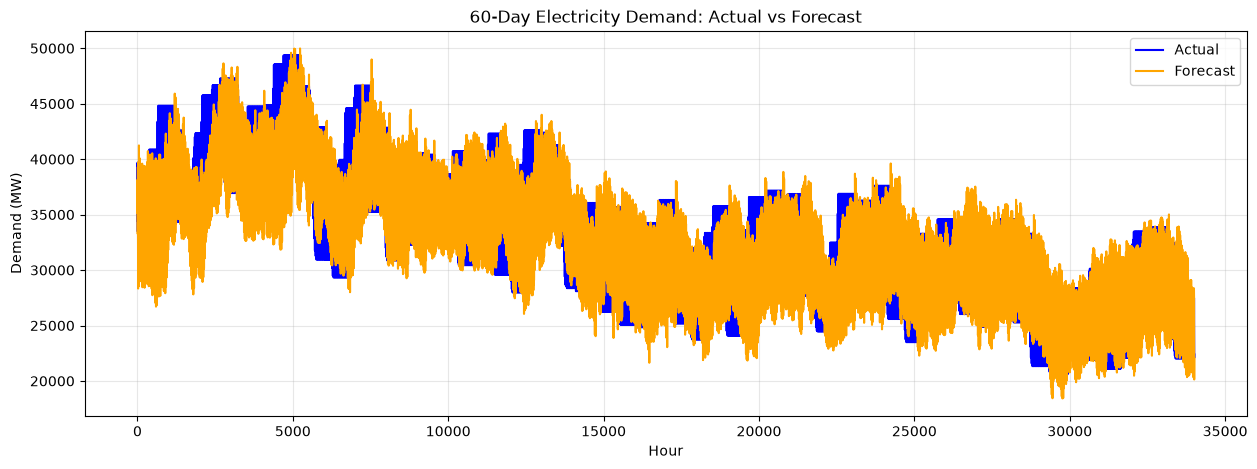

In [42]:
plt.figure(figsize=(15, 5))

plt.plot(
    actual_60_flat,
    label="Actual",
    color="blue"
)

plt.plot(
    forecast_60_flat,
    label="Forecast",
    color="orange"
)

plt.title(
    "60-Day Electricity Demand: Actual vs Forecast"
)

plt.xlabel("Hour")
plt.ylabel("Demand (MW)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()